# Example 01_synthetic_episode

Synthetic values (edit `config.json`). One closed bottleneck episode from queue to emissions: queued state, conservation, finite-link condition, and the two equivalent emission forms.

This notebook runs `run.py` in this folder and shows its outputs. Inputs are in `config.json`; expected values are in `expected/results.json`.

In [1]:
import json, runpy, sys
from pathlib import Path
from IPython.display import Image, display
HERE = Path.cwd()
try:
    runpy.run_path(str(HERE / 'run.py'), run_name='__main__')
except SystemExit as e:
    print('exit status', e.code)

SYNTHETIC EXAMPLE (illustrative values, not observed data)
1. queued state: omega = 12.00 mph, k_q = 75.00 veh/mi/lane, v_q = 20.00 mph
2. closed queue: D = mu P = 3000 veh/lane (numerical 3000.000); W_P = 44.444 veh h/lane (numerical 44.444); peak delay 1.580 min, mean delay 0.889 min; mean/peak = 0.5625 (9/16 for the Newell model only)
3. finite link: allowance L(1/vq - 1/vf) = 2.000 min; peak-delay vehicle fits (T_free = 0.210 min)
4. CO2: e0 = 277.80 g/veh, Gamma = 1772.36 g/(veh h), mean-delay vehicle e = 304.06 g;
   episode total 912.1717 kg/lane (delay form) = 912.1717 kg/lane (VMT/VHT form)
checks: conservation_D PASS, total_delay_W PASS, closed_queue PASS, peak_vehicle_fits_link PASS, two_forms_agree PASS


compared 29 values with expected/results.json: 29 agree
exit status 0


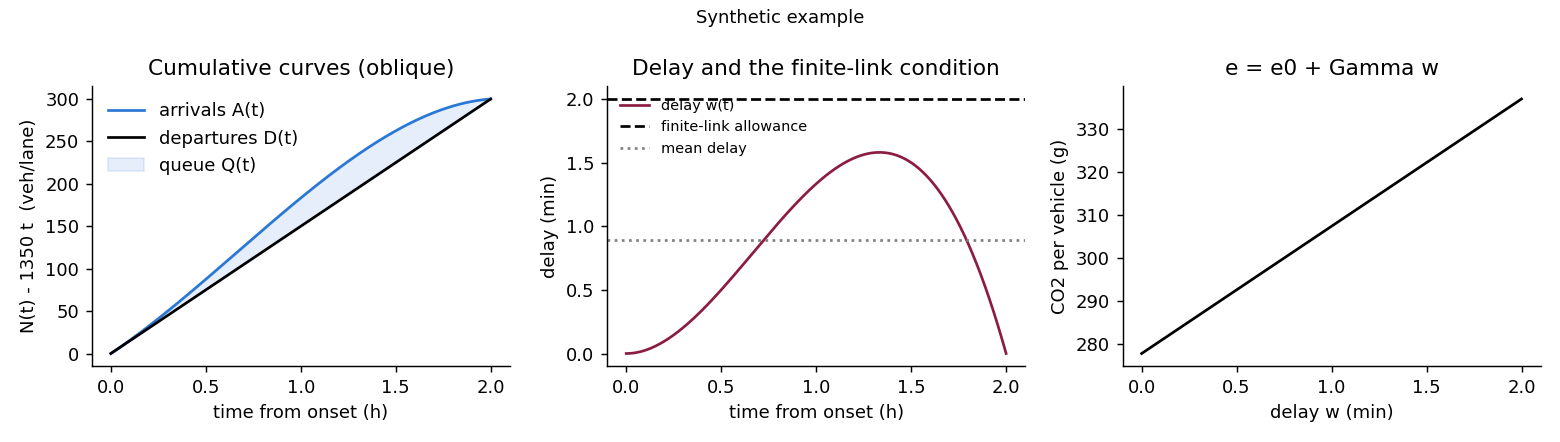

In [2]:
display(Image(filename=str(HERE / 'figure.png')))

In [3]:
res = json.loads((HERE / 'results.json').read_text())
print(json.dumps({k: v for k, v in res.items() if k != 'provenance'}, indent=1)[:3000])
print('provenance:', res['provenance'])

{
 "state": {
  "kc_veh_mi_lane": 33.333333333333336,
  "omega_mph": 12.0,
  "kq_veh_mi_lane": 75.0,
  "vq_mph": 20.0
 },
 "queue": {
  "D_veh_lane": 3000.0,
  "W_P_veh_h_lane": 44.44444444444444,
  "peak_delay_min": 1.5802469135802468,
  "mean_delay_min": 0.888888888888889,
  "mean_over_peak_newell": 0.5625,
  "numerical_D_veh_lane": 2999.99999166667,
  "numerical_W_P_veh_h_lane": 44.44443333333298,
  "numerical_closure_error_veh": 8.33332978800172e-06
 },
 "finite_link": {
  "allowance_min": 2.0000000000000004,
  "peak_vehicle_ok": true,
  "T_free_peak_vehicle_min": 0.20987654320987634,
  "T_queue_peak_vehicle_min": 2.3703703703703702
 },
 "emission": {
  "pollutant": "CO2",
  "e0_g_per_veh": 277.8000935144583,
  "Gamma_g_per_veh_h": 1772.3574613756334,
  "e_mean_vehicle_g": 304.05724109039363,
  "E_P_delay_form_kg_lane": 912.1717232711809,
  "E_P_vmt_vht_form_kg_lane": 912.1717232711809,
  "VMT_veh_mi": 3000.0,
  "VHT_veh_h": 94.44444444444446
 },
 "checks": {
  "conservation_D": tr